In [6]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import cosmology
import astropy.units as u
import cgm_sf_regulator

from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit

# import the newest model
from cgm_sf_regulator import CGMRegulator

# this is the C23 Model as Greg had it initially
from cgm_sf_regulator_baseline import CGMRegulatorBaseline

### setup cosmology

In [2]:
# standard flat cosmology
H0 = 70
Omegam0 = 0.3
Omegade0 = 0.7

Ob0 = 0.0490
f_b = Ob0 / Omegam0
LCDM = cosmology.LambdaCDM(H0=H0, Om0=Omegam0, Ode0=Omegade0)

 standard run of 1 halo via the CGMRegulator Class

 has some flags, but the documentation is ok

In [9]:
mhalo_z0 = 1e12 * u.Msun  # MW mass halo
t_span = (0.1, 13.3)  # gyrs, timestep automatricall determined by defualt

# declare model parameters
latest_model = CGMRegulator(
    mhalo_z0,
    t_span,
    tstep=0.005,
    add_f_prevent_floor=1e-8,  # virtually no floor
    KS_kappa_s=0.0464,  # still TBD, but latest working one
    KS_n=1.8,
    disk_scale_length=0.02,
    KS_parametrization="KS1998",
    TEST_tej_Tvir_definition=False,  # can set to True for testing, but not the default
)

# now to actually run
run_2phase = latest_model.run_halo()
results_2phase = latest_model.get_results()
derived_2phase = latest_model.get_derived_quantities()

_________________________________________
+++ running a model from z = 29.69 redshift to z = 0.01 redshift
self.time_interval (0.1, 13.3)
Initial halo mass (t = 0.10 Gyr) = 1.24e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 1.24e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 2.37e+46 erg
Starting ODE solver (perf_counter=460450.584996)


/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:88: RuntimeWarning: invalid value encountered in log10
  log_temp = np.log10(temperature)
/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:89: RuntimeWarning: invalid value encountered in log10
  log_metallicity = np.log10(metallicity)


ODE solver finished in 6.658 s (status=0, nfev=1448)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.01e+12 Msol	Initial halo mass = 1.24e+07 Msol	Final stellar mass = 2.54e+10 Msol	Peak halo scale efficiency = 1.65e-01	Final CGM mass = 1.32e+10 Msol	Final CGM metallicity = 8.92e-02	Final CGM energy = 6.54e+57 erg


to get results, both the integrated and derived quantities (like rates)

some of these are redundant

In [11]:
print(derived_2phase.keys())
print(results_2phase.keys())

dict_keys(['sim_time', 'z', 'halo_vir_temp', 'dot_e_cgm_out', 'dot_e_cgm_cooling', 'dot_e_cgm_in', 'dot_e_ism_wind', 'dot_m_cgm_out', 'dot_m_cgm_hot', 'dot_m_cgm_cold', 'dot_m_cgm_in', 'dot_m_ism_wind', 'f_prevent', 'halo_sfe', 't_dynamical', 'tcool_real', 'cooling_lambda', 'halo_rvir', 'dot_m_sfr', 'dot_mstar_central', 't_ejection', 'cgm_temp', 'rho0', 'dot_m_halo'])
dict_keys(['z', 't', 'm_ism', 'm_star', 'm_bulge', 'm_cgm', 'm_cgm_hot', 'm_cgm_cold', 'm_metals', 'm_halo', 'egy_ism_wind', 'egy_radloss', 'egy_eject', 'egy_cgm_in', 'egy_cgm', 'metal_cgm_mass', 'metal_cgm_mass_sol'])


plot the result, using Figure 2 of the paper

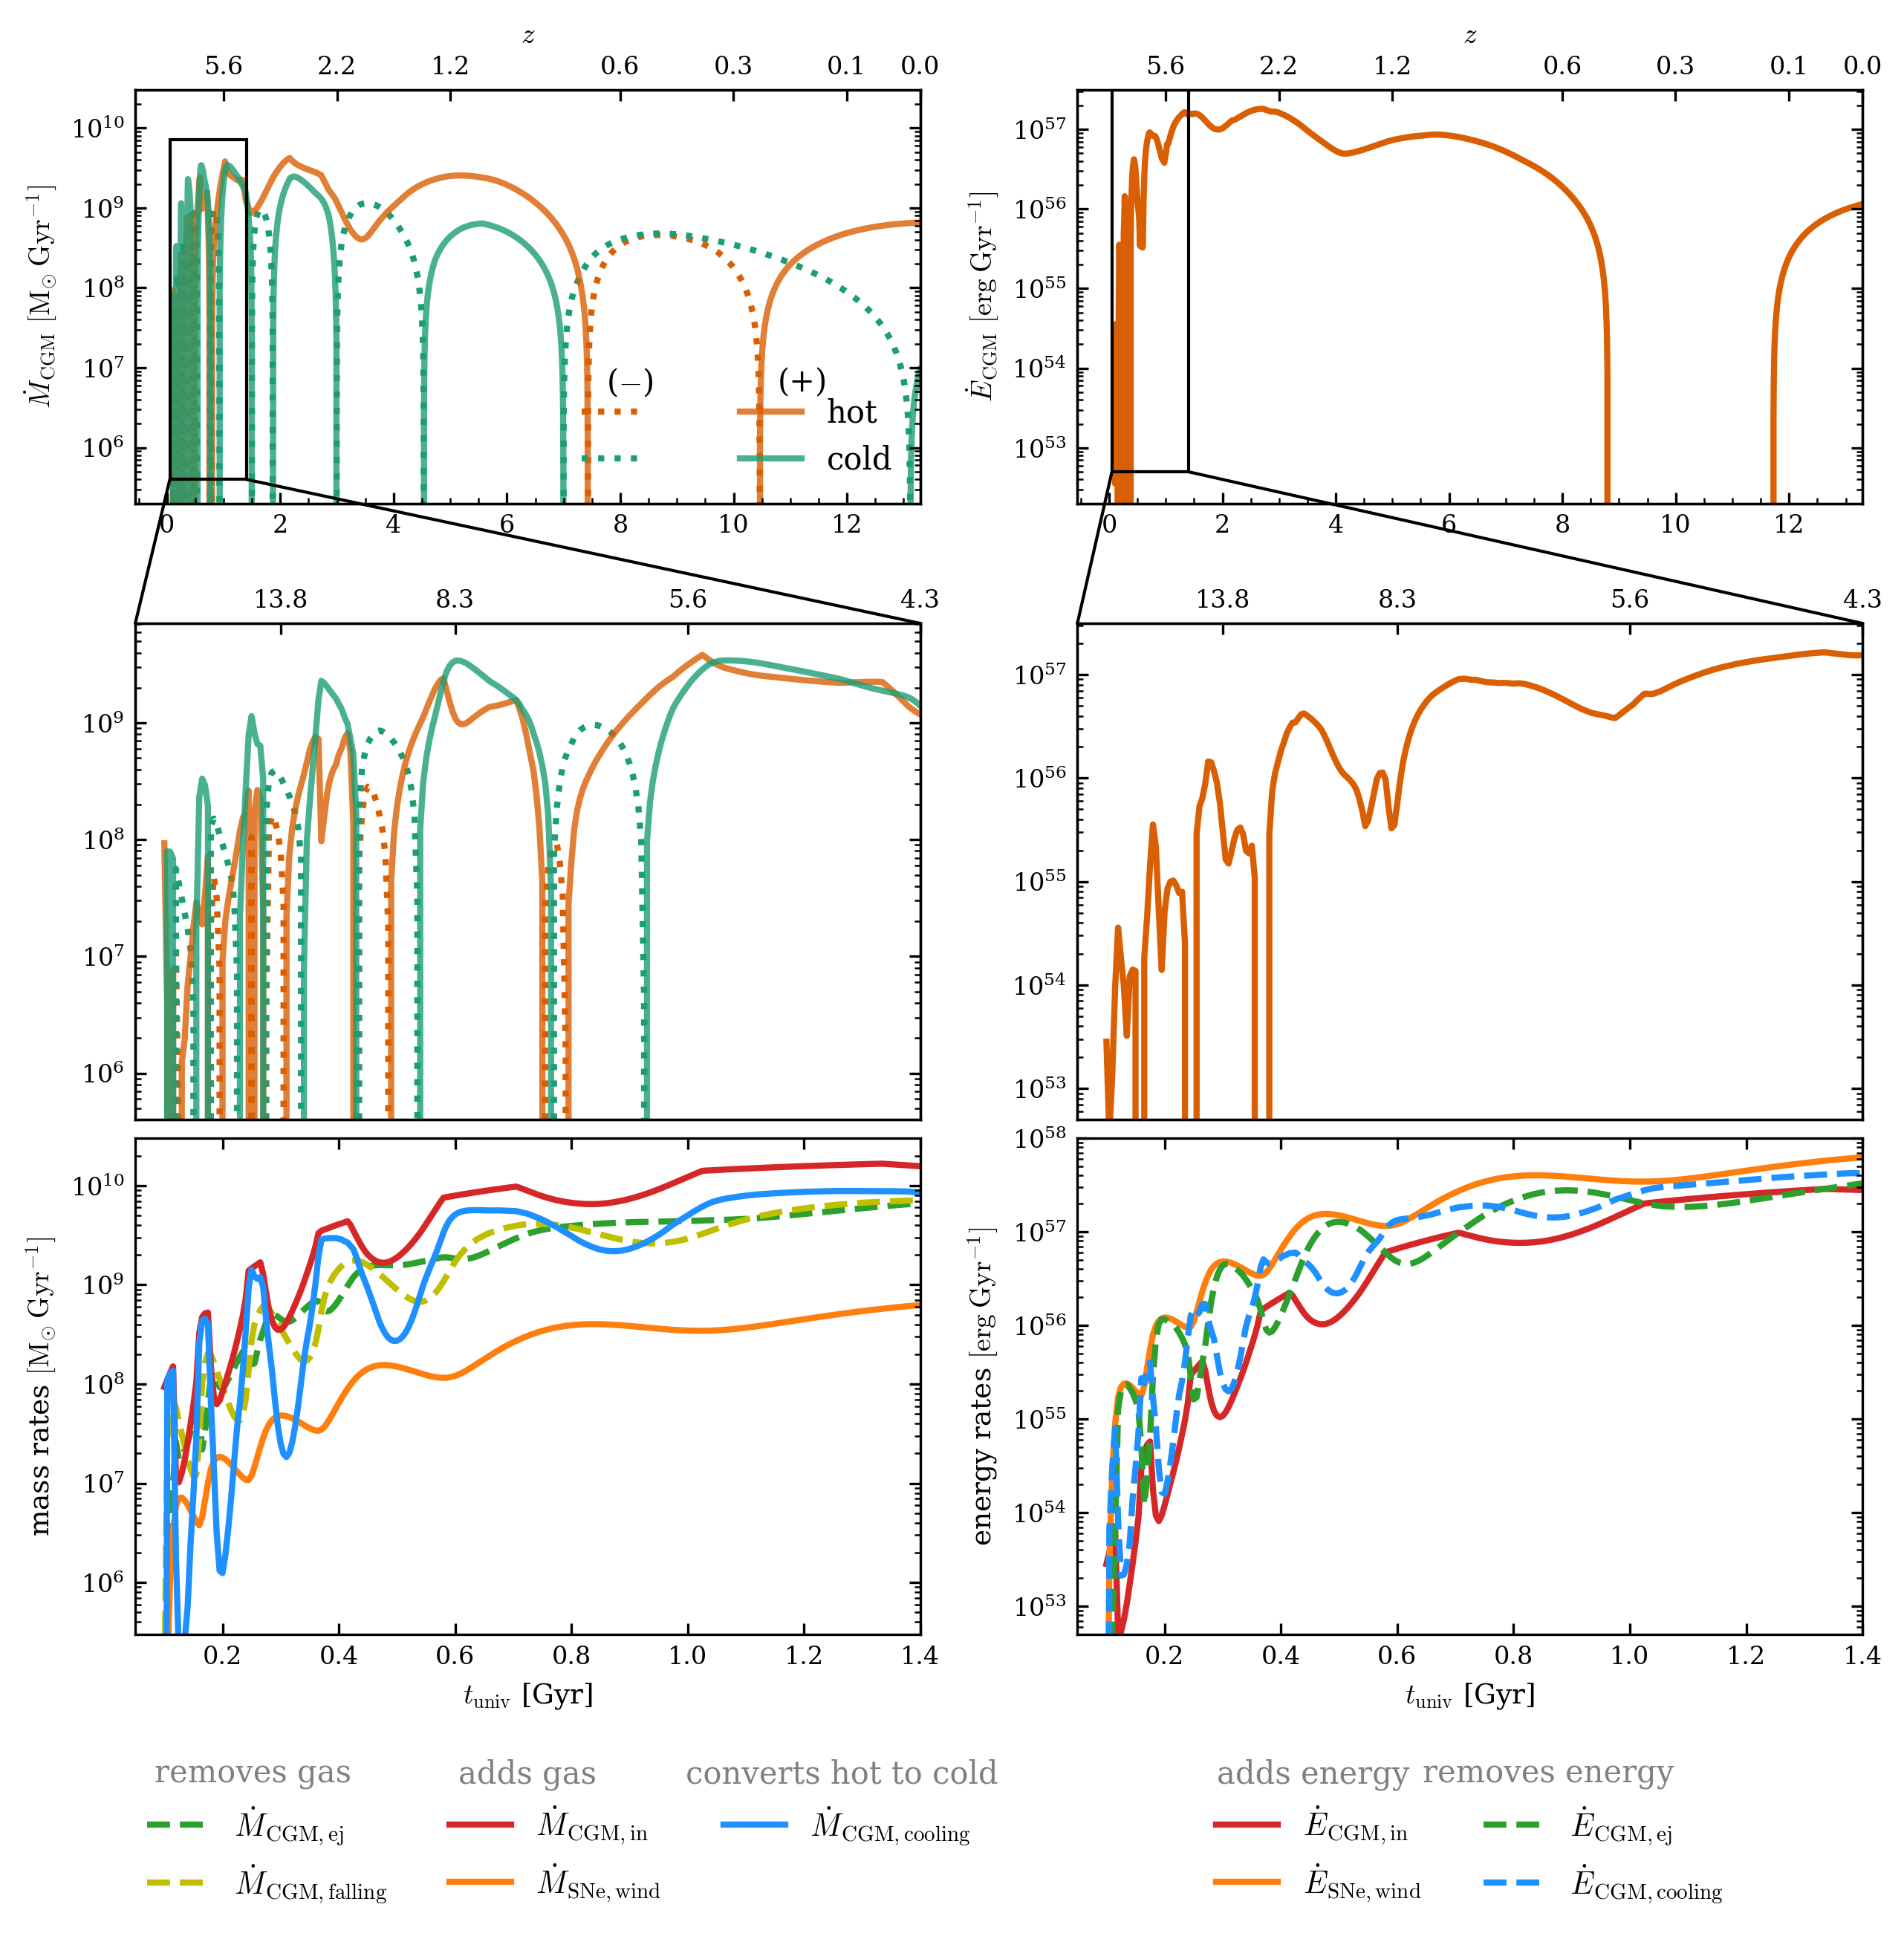

In [12]:
tmin = results_2phase["t"].min() * 0.1
tmax = results_2phase["t"].max()

red1 = "tab:red"
red2 = "tab:orange"
blu1 = "dodgerblue"
blu2 = "tab:green"

fig, ax = plt.subplots(
    4,
    2,
    figsize=(10, 9),
    dpi=300,
    gridspec_kw={"height_ratios": [2.5, 0.5, 3, 3]},
)
plt.subplots_adjust(hspace=0.05, wspace=0.2)
ax = ax.flatten()

cmap = plt.get_cmap("Dark2")
hot_clr = cmap(1)
col_clr = cmap(0)

cmapdark2 = plt.get_cmap("Dark2")
total_clr = cmapdark2(0)

# Panel 0: CGM mass rates
# let's also include the negative values and take absolute values and have that as dotted line
# neg_dot_m_cgm_hot_mask = derived_2phase["dot_m_cgm_hot"] < 0
# neg_dot_m_cgm_cold_mask = derived_2phase["dot_m_cgm_cold"] < 0

time_hot = results_2phase["t"]  # [neg_dot_m_cgm_hot_mask]
time_cold = results_2phase["t"]  # [neg_dot_m_cgm_cold_mask]

y_hot = -derived_2phase["dot_m_cgm_hot"]  # [neg_dot_m_cgm_hot_mask]
y_cold = -derived_2phase["dot_m_cgm_cold"]  # [neg_dot_m_cgm_cold_mask]

ax[0].plot(time_hot, y_hot, color=hot_clr, lw=2, ls=":", label=" ")

ax[0].plot(time_cold, y_cold, color=col_clr, lw=2, ls=":", label=" ")

ax[4].plot(time_hot, y_hot, color=hot_clr, lw=2, ls=":", label="")

ax[4].plot(time_cold, y_cold, color=col_clr, lw=2, ls=":", label="")

ax[0].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_hot"],
    color=hot_clr,
    lw=2,
    label=r"hot",
    alpha=0.8,
)
ax[0].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_cold"],
    color=col_clr,
    lw=2,
    label=r"cold",
    alpha=0.8,
)

ax[0].legend(frameon=False, ncol=2, loc="lower right", fontsize=10)
ax[0].set(
    ylabel=r"$\dot{M}_{\rm CGM}  ~ [{\rm M_{\odot}}\: {\rm Gyr^{-1}}]$",
    yscale="log",
    ylim=(2e5, 3e10),
)
ax[0].text(
    0.63,
    0.33,
    r"($-$)",
    transform=ax[0].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="k",
)
ax[0].text(
    0.85,
    0.33,
    r"(+)",
    transform=ax[0].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="k",
)

# Panel 3: CGM mass rates (inset range)
ax[4].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_hot"],
    color=hot_clr,
    lw=2,
    alpha=0.8,
    label=r"$\dot{M}_{\rm CGM, hot}$",
)
ax[4].plot(
    results_2phase["t"],
    derived_2phase["dot_m_cgm_cold"],
    color=col_clr,
    lw=2,
    alpha=0.8,
    label=r"$\dot{M}_{\rm CGM, cold}$",
)
ax[4].set(yscale="log", xlim=(0.05, 1.4), ylim=(4e5, None))

# Panel 1: CGM energy rates
dot_e_sne_wind = derived_2phase["dot_e_ism_wind"]
dot_e_cgm_acc = derived_2phase["dot_e_cgm_in"]
dot_e_cgm_cool = derived_2phase["dot_e_cgm_cooling"]
dot_e_cgm_ej = derived_2phase["dot_e_cgm_out"]
dot_e_cgm_total = dot_e_cgm_acc + dot_e_sne_wind - dot_e_cgm_ej - dot_e_cgm_cool

ax[1].plot(
    results_2phase["t"],
    dot_e_cgm_total,
    color=hot_clr,
    lw=2,
    # label=r"$\dot{E}_{\rm CGM, total}$",
)
ax[1].set(
    ylabel=r"$\dot{E}_{\rm CGM}~ [{\rm erg\: Gyr^{-1}}]$",
    yscale="log",
    ylim=(2e52, None),
)
# ax[1].legend(frameon=False, ncol=1, loc="lower right")

# Panel 4: CGM energy rates (inset range)
ax[5].plot(
    results_2phase["t"],
    dot_e_cgm_total,
    color=hot_clr,
    lw=2,
    label=r"$\dot{E}_{\rm CGM}$",
)
ax[5].set(yscale="log", xlim=(0.05, 1.4), ylim=(5e52, None))

# --- Custom connectors ---
# Connector 1: top-left of zoom region in parent → top-left corner of inset
con1 = ConnectionPatch(
    xyA=(0, 1),
    coordsA=ax[5].transAxes,
    xyB=(0.05, 5e52),
    coordsB=ax[1].transData,
    color="k",
    lw=1,
    zorder=10,
)

# Connector 2: bottom-right of zoom region in parent → bottom-right corner of inset
con2 = ConnectionPatch(
    xyA=(1, 1),
    coordsA=ax[5].transAxes,
    xyB=(1.4, 5e52),
    coordsB=ax[1].transData,
    color="k",
    lw=1,
    zorder=10,
)
ax[1].figure.add_artist(con1)
ax[1].figure.add_artist(con2)
artists = mark_inset(
    ax[1],
    ax[5],
    loc1=2,
    loc2=4,
    fc="none",
    color="k",
    zorder=10,
)
for line in artists[1:]:
    line.set_alpha(0.0)

# Connector 1: top-left of zoom region in parent → top-left corner of inset
con1 = ConnectionPatch(
    xyA=(0, 1),
    coordsA=ax[4].transAxes,  # UL corner of inset
    xyB=(0.05, 4e5),
    coordsB=ax[0].transData,  # UL of parent zoom
    color="k",
    lw=1,
    zorder=10,
)
ax[0].figure.add_artist(con1)

# Connector 2: bottom-right of zoom region in parent → bottom-right corner of inset
con2 = ConnectionPatch(
    xyA=(1, 1),
    coordsA=ax[4].transAxes,  # LR corner of inset
    xyB=(1.4, 4e5),
    coordsB=ax[0].transData,  # LR of parent zoom
    color="k",
    lw=1,
    zorder=10,
)
ax[0].figure.add_artist(con2)

# --- Draw rectangle only, hide default connectors ---
artists = mark_inset(ax[0], ax[4], loc1=2, loc2=4, fc="none", color="k", zorder=10)
for line in artists[1:]:
    line.set_alpha(0.0)

# Panels 2 and 3: ghost rows for spacing only, no plots
ax[2].axis("off")
ax[3].axis("off")

# Panel 4: CGM mass rates (zoomed)
dot_m_cgm_cooling = results_2phase["m_cgm_hot"] / derived_2phase["tcool_real"]
dot_m_cgm_in = derived_2phase["dot_m_cgm_in"]
dot_m_sne_wind = derived_2phase["dot_m_ism_wind"]
dot_m_cgm_ej = derived_2phase["dot_m_cgm_out"]
dot_cgm_falling = results_2phase["m_cgm_cold"] / derived_2phase["t_dynamical"]

ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_ej,
    lw=2,
    ls="--",
    label=r"$\dot{M}_{\rm CGM, ej}$",
    color=blu2,
)
ax[6].plot(
    results_2phase["t"],
    dot_cgm_falling,
    lw=2,
    ls="--",
    label=r"$\dot{M}_{\rm CGM, falling}$",
    color="y",
)

ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_in,
    lw=2,
    label=r"$\dot{M}_{\rm CGM, in}$",
    color=red1,
)
ax[6].plot(
    results_2phase["t"],
    dot_m_sne_wind,
    lw=2,
    label=r"$\dot{M}_{\rm SNe, wind}$",
    color=red2,
)


ax[6].set(
    ylabel=r"mass rates $[{\rm M_{\odot}}\: {\rm Gyr^{-1}}]$",
    yscale="log",
    ylim=(3e5, 3e10),
    xlabel=r"$t_{\rm univ}$ [Gyr]",
    xlim=(0.05, 1.4),
)
ax[6].plot(
    results_2phase["t"],
    dot_m_cgm_cooling,
    lw=2,
    ls="-",
    label=r"$\dot{M}_{\rm CGM, cooling}$",
    color=blu1,
)
ax[6].legend(
    frameon=False, ncol=3, fontsize=10, loc="lower right", bbox_to_anchor=(1.1, -0.6)
)

ax[6].text(
    0.15,
    -0.25,
    r"removes gas",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[6].text(
    0.5,
    -0.25,
    r"adds gas",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[6].text(
    0.9,
    -0.25,
    "converts hot to cold",
    transform=ax[6].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)

# Panel 5: CGM energy rates (zoomed)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_acc,
    color=red1,
    lw=2,
    label=r"$\dot{E}_{\rm CGM, in}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_sne_wind,
    color=red2,
    lw=2,
    label=r"$\dot{E}_{\rm SNe, wind}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_ej,
    color=blu2,
    lw=2,
    ls="--",
    label=r"$\dot{E}_{\rm CGM, ej}$",
)
ax[7].plot(
    results_2phase["t"],
    dot_e_cgm_cool,
    color=blu1,
    ls="--",
    lw=2,
    label=r"$\dot{E}_{\rm CGM, cooling}$",
)
ax[7].set(
    ylabel=r"energy rates $[{\rm erg\: Gyr^{-1}}]$",
    yscale="log",
    ylim=(5e52, 1e58),
    xlim=(0.05, 1.4),
    xlabel=r"$t_{\rm univ}$ [Gyr]",
)
ax[7].legend(
    frameon=False, ncol=2, fontsize=10, loc="lower center", bbox_to_anchor=(0.5, -0.6)
)

# first column of the legend add energy to the CGM , 2nd removes, add text annotation
ax[7].text(
    0.3,
    -0.25,
    r"adds energy",
    transform=ax[7].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)
ax[7].text(
    0.6,
    -0.25,
    r"removes energy",
    transform=ax[7].transAxes,
    fontsize=10,
    ha="center",
    va="top",
    color="grey",
)

# make a twin redshift axis for the top row, using z
t_ticks = np.array([1, 3, 5, 8, 10, 12, 13.3])
z_ticks = [cosmology.z_at_value(LCDM.age, t * u.Gyr).value for t in t_ticks]

for i in [0, 1]:
    ax2 = ax[i].twiny()
    ax2.plot(results_2phase["t"], derived_2phase["dot_m_cgm_hot"], color="k", alpha=0)
    ax2.set_xlim((None, tmax))
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels(["{:.1f}".format(z) for z in z_ticks])
    ax2.set_xlabel(r"$z$")
    ax2.minorticks_off()
    ax[i].minorticks_on()
    ax[i].set_xlim((None, tmax))

t_ticks = np.array([0.3, 0.6, 1, 1.4])
z_ticks = [cosmology.z_at_value(LCDM.age, t * u.Gyr).value for t in t_ticks]
for i in [4, 5]:
    ax2 = ax[i].twiny()
    ax2.plot(results_2phase["t"], derived_2phase["dot_m_cgm_hot"], color="k", alpha=0)
    ax2.set_xlim((0.05, 1.4))
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels(["{:.1f}".format(z) for z in z_ticks])
    # ax2.set_xlabel(r"$z$")
    ax2.minorticks_off()
    ax[i].minorticks_on()
    ax[i].set_xlim((0.05, 1.4))
    # turn x axis ticks off
    ax[i].set_xticks([])

for axes in ax:
    for line in axes.lines:
        line.set_zorder(1)

# plt.savefig(
#     "./figures/fig_2phase_detailed_cgm_1e12.png",
#     dpi=200,
#     bbox_inches="tight",
#     pad_inches=0.05,
# )
plt.show()

we can also do grids of models, i.e., a range of halo massses at a certain observed redshift

below, we'll do the gas fractions

In [29]:
from run_grids_of_models import (
    run_baseline_model_redshift_grid,
    run_2phase_model_redshift_grid,
)
import astropy.units as u
import astropy.constants as consts
import os
import cmasher as cmr
from labellines import labelLine, labelLines
import h5py
from matplotlib.lines import Line2D
import pandas as pd
from astropy.table import Table

In [32]:
## some chosen KS98 param
n_sfr = 1.8
r_disk_sfr = 0.02
kappa_sfr = 0.03

[11.0, 8.0, 7.0, 6.0, 4.0, 2.75, 2.25, 0.35, 0.01]
[1.00000000e+10 2.15443469e+10 4.64158883e+10 1.00000000e+11
 2.15443469e+11 4.64158883e+11 1.00000000e+12 2.15443469e+12
 4.64158883e+12 1.00000000e+13] solMass
running 2-phase model grid... ./runs/smhm_2phase_redshift_scan_KS_1998_kappa0p03_n1p8_r0p02.h5
** t_final = 0.41

* observing halo with mass 1.00e+10 solMass at z = 11.00
** mass of halo at z=0 is 7.62e+12 solMass
_________________________________________
+++ running a model from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829)
Initial halo mass (t = 0.10 Gyr) = 2.28e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 2.28e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg

/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:88: RuntimeWarning: invalid value encountered in log10
  log_temp = np.log10(temperature)
/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:89: RuntimeWarning: invalid value encountered in log10
  log_metallicity = np.log10(metallicity)


ODE solver finished in 5.393 s (status=0, nfev=1250)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.01e+10 Msol	Initial halo mass = 2.28e+07 Msol	Final stellar mass = 7.66e+07 Msol	Peak halo scale efficiency = 4.72e-02	Final CGM mass = 5.50e+08 Msol	Final CGM metallicity = 2.93e-02	Final CGM energy = 5.86e+55 erg
** final halo mass = 1.01e+10

* observing halo with mass 2.15e+10 solMass at z = 11.00
** mass of halo at z=0 is 3.58e+13 solMass
_________________________________________
+++ running a model from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829)
Initial halo mass (t = 0.10 Gyr) = 3.45e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 3.45e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 e

/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Initial halo mass (t = 0.10 Gyr) = 1.08e+08 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 1.08e+08 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 8.04e+47 erg
Starting ODE solver (perf_counter=461990.864640)
ODE solver finished in 4.419 s (status=0, nfev=842)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 2.19e+11 Msol	Initial halo mass = 1.08e+08 Msol	Final stellar mass = 4.47e+09 Msol	Peak halo scale efficiency = 1.28e-01	Final CGM mass = 1.86e+10 Msol	Final CGM metallicity = 5.62e-02	Final CGM energy = 6.32e+57 erg
** final halo mass = 2.19e+11

* observing halo with mass 4.64e+11 solMass at z = 11.00
** mass of halo at z=0 is 1.18e+17 solMass
_________________

/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:1159: RuntimeWarning: invalid value encountered in scalar power
  dot_m_star = self.ks_kappa_s * Asfr * (sigma0/ Sigma1_kpc2.value) ** self.ks_n * (2 * np.pi * r_disk_kpc**2  / self.ks_n**2) # Msun / year
/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:1196: RuntimeWarning: invalid value encountered in scalar power
  dot_m_bulge = (2.0 * np.pi * Asfr * sigma0**self.ks_n) / (self.ks_n**2)


ODE solver finished in 4.688 s (status=0, nfev=1004)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 2.19e+11 Msol	Initial halo mass = 4.76e+07 Msol	Final stellar mass = 5.55e+09 Msol	Peak halo scale efficiency = 1.58e-01	Final CGM mass = 1.59e+10 Msol	Final CGM metallicity = 7.22e-02	Final CGM energy = 4.89e+57 erg
** final halo mass = 2.19e+11

* observing halo with mass 4.64e+11 solMass at z = 8.00
** mass of halo at z=0 is 6.46e+14 solMass
_________________________________________
+++ running a model from z = 29.69 redshift to z = 8.00 redshift
self.time_interval (0.1, 0.629363398460329)
Initial halo mass (t = 0.10 Gyr) = 6.59e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 6.59e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	

/home/fabg/highzBHsandClusters/cgm_sf_regulator.py:88: RuntimeWarning: divide by zero encountered in log10
  log_temp = np.log10(temperature)


ODE solver finished in 6.132 s (status=0, nfev=1406)
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 2.19e+10 Msol	Initial halo mass = 1.31e+07 Msol	Final stellar mass = 1.82e+08 Msol	Peak halo scale efficiency = 5.20e-02	Final CGM mass = 9.78e+08 Msol	Final CGM metallicity = 3.30e-02	Final CGM energy = 1.42e+56 erg
** final halo mass = 2.19e+10

* observing halo with mass 4.64e+10 solMass at z = 7.00
** mass of halo at z=0 is 3.86e+12 solMass
_________________________________________
+++ running a model from z = 29.69 redshift to z = 7.00 redshift
self.time_interval (0.1, 0.750813984809555)
Initial halo mass (t = 0.10 Gyr) = 1.87e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 1.87e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	

/home/fabg/.pyenv/versions/3.8.10/lib/python3.8/site-packages/labellines/core.py:208: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=9402932.965942383, xmax=559918875763.5607, xval=1000000000000.0). Clipping it into the allowed range.
  warnings.warn(


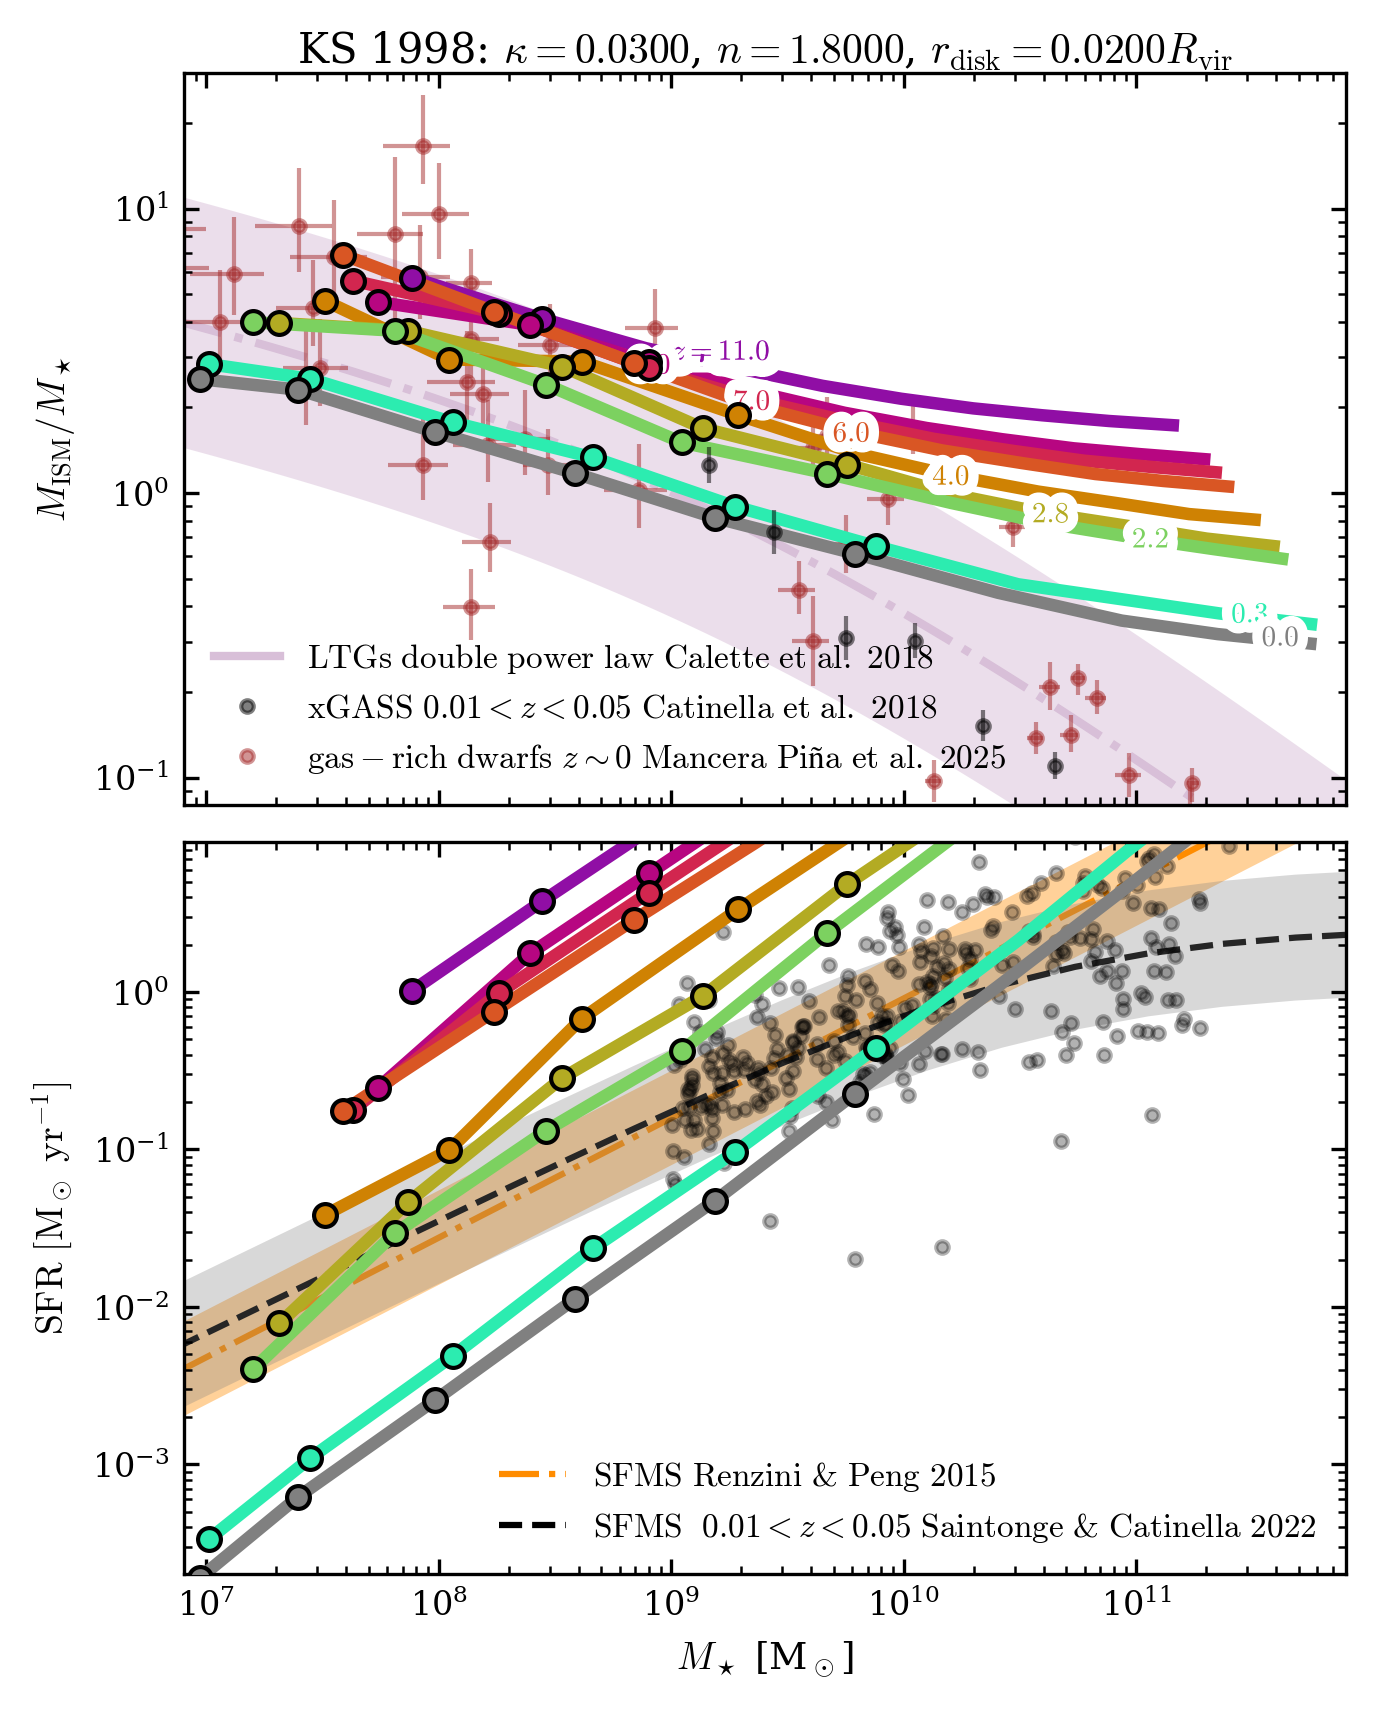

In [33]:
def virial_T(mhalo, Rvir):
    """# calculate corresponding virial temperatures

    Args:
        mhalo (_type_): halo mass
        Rvir (_type_): halo virial radius

    Returns:
        _type_: virial temperture
    """
    G = consts.G
    kb = consts.k_B
    mp = consts.m_p
    return ((2 / 5) * ((G * mhalo * mp) / (Rvir * kb))).to(u.K)


def virial_radius(z, mhalo, Delc=200):
    """
    Halo virial radius, classical 200 top-hat overdensity.
    Supports z as a 1D array and mhalo as a 2D array (shape: [len(z), N]).
    Args:
        z (array-like): Redshift array of shape (len(z),)
        mhalo (array-like): Halo mass array of shape (len(z), N)
        Delc (float): Overdensity parameter (default: 200)
    Returns:
        ndarray: Virial radius array of shape (len(z), N)
    """
    z = np.asarray(z)

    # Broadcast critical density to shape (len(z), 1)
    rhoc = LCDM.critical_density(z)[:, np.newaxis]
    rvir = (mhalo / (rhoc * (4 / 3) * np.pi * Delc)) ** (1 / 3)

    return rvir.to(u.kpc)


def circular_velocity(mhalo, Rvir):
    """circular velocity of the halo"""
    G = consts.G
    return np.sqrt(G * mhalo / Rvir).to(u.km / u.s)


def vcirc_from_virial_T(Tvir, mu=0.59):
    kb = consts.k_B
    mp = consts.m_p
    return np.sqrt((2 * kb * Tvir) / (mu * mp)).to(u.km / u.s)


zbins_str = [
    "0.2 < z < 0.5",
    "2.0 < z < 2.5",
    "2.5 < z < 3.0",
    "3.5 < z < 4.5",
    "5.5 < z < 6.5",
    "6.5 < z < 7.5",
    "7.5 < z < 8.5",
    "10.0 < z < 12.0",
]

# make a color map with the same number of colors as the number of zbins_str
cmap = cmr.tropical
cmap_colors = [cmap(i / len(zbins_str)) for i in range(len(zbins_str))]

zbins_ctr = []  # get the center value of zbins_str
for zb in zbins_str:
    z = zb.split("<")
    z = (float(z[0]) + float(z[2])) / 2
    zbins_ctr.append(z)

smf_data = Table.read("./data/Shuntov2024-shmr.ecsv", format="ascii.ecsv")

# define empty dictionaries to store values for each z-bin
Mhalo = {}
Mstar = {}
Mstar_low = {}
Mstar_up = {}
# read for each z-bin
for zb in zbins_str:
    Mhalo[zb] = smf_data[smf_data["Redshift"] == zb]["M_halo"]
    Mstar[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_50"]
    Mstar_low[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_16"]
    Mstar_up[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_84"]

# reverse zbins_ctr to match the order of the data
zbins_ctr = zbins_ctr[::-1]
zbins_ctr.append(0.01)  # this is the lowest redshift bin

mass_bins = 10
zobs = zbins_ctr
# make a unique halo array for each redshift
mhalos = np.geomspace(1e10, 1e13, mass_bins)
mhalos = np.broadcast_to(mhalos, (len(zobs), mhalos.size)) * u.Msun
print(zobs)
print(mhalos[0])

#### XXX
param_txt = (
    f"KS_1998_kappa{str(kappa_sfr).replace('.', 'p')}_"
    + f"n{str(n_sfr).replace('.', 'p')}_"
    + f"r{str(r_disk_sfr).replace('.', 'p')}"
)
file = "./runs/smhm_2phase_redshift_scan_" f"{param_txt}.h5"
####

if not os.path.exists(file):
    print("running 2-phase model grid...", file)
    redshift_variation, zsims = run_2phase_model_redshift_grid(
        observe_at=zobs,  # redshift we want to observe
        mhalos=mhalos,
        write_to_file=file,
        disk_scale_length=r_disk_sfr,
        KS_n=n_sfr,
        KS_kappa_s=kappa_sfr,
        # add_f_prevent_floor=1e-6
    )


f = h5py.File(file, "r")
smhm_normalized = f["SMHM"]  # smhm is already normalized by baryon fractions
mhalo_obs = f["Mhalo_obs"]
mstar = f["Mstar_obs"]
mism = f["MISM_obs"]
zs = f["redshifts"][:]
sfr = f["SFR_obs"]
mmetal_cgm = f["MMetals_obs"]
rvirs = virial_radius(zs, mhalo_obs * u.Msun)  # virial radius in kpc
halo_Tvirs = virial_T(mhalo_obs * u.Msun, rvirs)  # virial temperature in K
print(f.keys())
print(f["redshifts"][:])


fig, ax = plt.subplots(2, 1, figsize=(5, 6.5), dpi=300, sharex=True, sharey="row")
ax = ax.flatten()
plt.subplots_adjust(hspace=0.05)
# get a colormap from cmasher
cmap = plt.get_cmap("cmr.tropical")
colors = cmap(np.linspace(0, 1, len(zs)))
# replace the final color with grey for the lowest redshift
colors[-1] = [0.5, 0.5, 0.5, 1.0]
Tvir_max = 1e6 * u.K
# loop through redshift and plot mgas/mstar vs mstar
for i, z in enumerate(zs):
    Tvirs = halo_Tvirs[i]
    mask = Tvirs < Tvir_max

    ax[0].plot(
        mstar[i], mism[i] / mstar[i], color=colors[i], label=r"${:.1f}$".format(z), lw=3
    )
    ax[0].scatter(
        mstar[i][mask],
        mism[i][mask] / mstar[i][mask],
        s=30,
        color=colors[i],
        edgecolor="k",
        zorder=3,
    )

    t_depletion = mism[i] / sfr[i]
    sSFR_Gyr = sfr[i] / mstar[i]  # Gyr^-1
    sSFR_yr = sSFR_Gyr * 1e-9
    sfr_yr = sfr[i] * 1e-9
    ax[1].plot(mstar[i], sfr_yr, color=colors[i], lw=3)
    ax[1].scatter(
        mstar[i][mask], sfr_yr[mask], s=30, color=colors[i], edgecolor="k", zorder=3
    )

lines = ax[0].get_lines()
l1 = lines[0]
labelLine(
    l1,
    1e9,
    label=r"$z={}$".format(zs[0]),
    align=False,
    yoffset=0.0,
    ha="left",
    backgroundcolor="none",
    fontsize=7,
    # color="black",
)
labelLines(
    lines[1:],
    xvals=np.geomspace(1e9, 1e12, len(lines) - 1),
    yoffsets=0.01,
    align=False,
    fontsize=7,
    ha="right",
    backgroundcolor="none",
    # color="black",
)


### ============== observations for comparison ============== ==============

## xGass: Catinella et al: https://ui.adsabs.harvard.edu/abs/2018MNRAS.476..875C/abstract

# total Mgas/Mstar vs Mstar, table 2 average values per bin
catinella_mstar = 10 ** np.array([9.16, 9.44, 9.75, 10.05, 10.34, 10.65, 10.95, 11.21])
catinella_mgas_mstar = 10 ** np.array(
    [0.098, -0.136, -0.509, -0.518, -0.817, -0.958, -1.190, -1.328]
)
catinella_mgas_mstar_err = np.array(
    [0.064, 0.077, 0.076, 0.062, 0.055, 0.048, 0.048, 0.064]
)
yerr_lower = catinella_mgas_mstar * (1 - 10 ** (-catinella_mgas_mstar_err))
yerr_upper = catinella_mgas_mstar * (10 ** (catinella_mgas_mstar_err) - 1)
yerr = np.vstack([yerr_lower, yerr_upper])

# here for the raw counts, unbinnned unlike above, using the full table
# https://xgass.icrar.org/assets/data/xGASS_representative_sample.readme
# https://xgass.icrar.org/assets/data/xGASS_representative_sample.ascii
# 0.01 < z < 0.05 Catinella+18 still, but for some reason don't have full gas fraction so using binned values
xGass_dat = pd.read_csv(
    "./data/xGass.txt",
    delim_whitespace=True,
)
xgas_sfrbest = xGass_dat["SFR_best"]  # msun /year
xgas_mstar = 10 ** xGass_dat["lgMstar"]
detection_tag = xGass_dat["HIsrc"]  # 1 for detection, 0 for upper limit
alfalfa_tag = 1
mask = detection_tag == alfalfa_tag  # only the gas rich alfalfa detections
ax[0].errorbar(
    catinella_mstar,
    catinella_mgas_mstar,
    yerr=yerr,
    fmt="o",
    color="k",
    markersize=3,
    alpha=0.5,
    elinewidth=1,
)
ax[1].errorbar(
    xgas_mstar[mask],
    np.array(xgas_sfrbest[mask]),
    color="k",
    markersize=3,
    fmt="o",
    alpha=0.3,
    zorder=1,
)

## Callette relation https://arxiv.org/pdf/1803.07692, late type galaxy Rgas-Mstar
log_C_ltg = 4.76
log_C_err = 0.05
a_ltg = -0.52
a_err = 0.03
intrinsic_scatter_dex = 0.44

### early type galaxies
log_C_etg = 3.70
a_etg = -0.58
intrinsic_scatter_dex_etg = 0.68

# Plot Calette relation: y(M*) = C * (M*/M_sun)^a
log_m_star_thry = np.linspace(6, 12, 100)
m_star_thry = 10**log_m_star_thry

# y_catinella_etg = 10**log_C_etg * (m_star_thry)**a_etg
# ax[0].plot(m_star_thry, y_catinella_etg, ls='--', color='k', lw=2, label='Callette+18 ETG', zorder=2)

# now the late type galaxies
y_catinella_ltg = 10**log_C_ltg * (m_star_thry) ** a_ltg
scatter_ltg = 0.44

y_upper = y_catinella_ltg * 10**scatter_ltg
y_lower = y_catinella_ltg / 10**scatter_ltg
# ax[0].plot(
#     m_star_thry,
#     y_catinella_ltg,
#     ls="-",
#     color="k",
#     lw=2,
#     label="Callette+18 LTG",
#     zorder=0,
# )
# ax[0].fill_between(m_star_thry, y_lower, y_upper, facecolor='k', alpha=0.2, zorder=0)

# Calette but double power law, still LTG
C = 1.69
a = 0.18
b = 0.61
log_Mtrunc = 9.2
intrinsic_scatter_dbl_pl = 0.44
y_dbl_power = C / (
    (m_star_thry / 10**log_Mtrunc) ** (a) + (m_star_thry / 10**log_Mtrunc) ** b
)
ax[0].plot(
    m_star_thry,
    y_dbl_power,
    ls="-.",
    color="thistle",
    lw=2,
    label="Calette+18 LTG DPL",
    zorder=0,
)
y_dbl_power_upper = y_dbl_power * 10**intrinsic_scatter_dbl_pl
y_dbl_power_lower = y_dbl_power / 10**intrinsic_scatter_dbl_pl
ax[0].fill_between(
    m_star_thry,
    y_dbl_power_lower,
    y_dbl_power_upper,
    facecolor="thistle",
    alpha=0.5,
    zorder=0,
)


x_theory = np.geomspace(1e6, 1e12, 20)  # some theory lines


# Renzini & Peng 2015 SFMS with 0.3 dex scatter
def logSFR_with_errors(
    Mstar, slope=0.76, dslope=0.01, intercept=-7.64, dintercept=0.02
):
    """Renzini & Peng (2015)

    https://ui.adsabs.harvard.edu/abs/2015ApJ...801L..29R/abstract
    """
    logM = np.log10(Mstar)
    logSFR = slope * logM + intercept
    sigma = np.sqrt((dslope * logM) ** 2 + dintercept**2)
    return logSFR, sigma


logSFR, sigma = logSFR_with_errors(x_theory)
sigma_3dex = 0.3  # added 0.3 dex according to paper
SFR = 10**logSFR
SFR_lo = 10 ** (logSFR - sigma_3dex)
SFR_hi = 10 ** (logSFR + sigma_3dex)
ax[1].fill_between(
    x_theory,
    SFR_lo,
    SFR_hi,
    facecolor="darkorange",
    alpha=0.4,
    zorder=0,
)
ax[1].plot(
    x_theory,
    SFR,
    ls="-.",
    color="darkorange",
    zorder=0,
    label=r"${\rm SFMS~ Renzini ~& ~Peng ~2015}$",
)


## Saintonge and Catinella 2022: https://ui.adsabs.harvard.edu/abs/2022ARA%26A..60..319S/abstract
def logSFR_MS_Saintonge_Catinella(Mstar):
    """
    from https://ui.adsabs.harvard.edu/abs/2022ARA%26A..60..319S/abstract
    this is derived from m Saintonge et al. (2017).
    Parameters
    ----------
    Mstar : array_like
        Stellar mass in solar masses (NOT logged)

    Returns
    -------
    logSFR : ndarray
        log10(SFR / Msun yr^-1)
    """
    M0 = 10**10.59
    alpha = -0.718
    logsfr = 0.412 - np.log10(1.0 + (Mstar / M0) ** alpha)
    return 10**logsfr


ax[1].plot(
    x_theory,
    logSFR_MS_Saintonge_Catinella(x_theory),
    ls="--",
    color="k",
    zorder=0,
    label=r"${\rm SFMS~}$"
    + r"$~0.01 < z < 0.05$"
    + r"${~\rm Saintonge ~& ~Catinella ~2022}$",
)

# add 0.4 dex scatter region
ax[1].fill_between(
    x_theory,
    logSFR_MS_Saintonge_Catinella(x_theory) * 10 ** (-0.4),
    logSFR_MS_Saintonge_Catinella(x_theory) * 10 ** (0.4),
    facecolor="grey",
    alpha=0.3,
    zorder=0,
)
# ax[1].fill_between(
#     x_theory_extrapolation,
#     logSFR_MS_Saintonge_Catinella(x_theory_extrapolation) * 10**(-0.4),
#     logSFR_MS_Saintonge_Catinella(x_theory_extrapolation) * 10**(0.4),
#     facecolor="tab:orange",
#     alpha=0.3,
#     zorder=0,
# )


# dwarf data from ManceraPina25_dwarfs.txt, Table G.2 of https://arxiv.org/pdf/2505.22727
dwarf_data = np.loadtxt("./data/ManceraPina25_dwarfs.txt", skiprows=2)

# all values are given in log
logMstar = dwarf_data[:, 0]  # log(Mstar)
logMstar_lo = dwarf_data[:, 1]  # lower sigma in log space
logMstar_hi = dwarf_data[:, 2]  # upper sigma in log space

logMgas = dwarf_data[:, 3]  # log(Mgas)
logMgas_lo = dwarf_data[:, 4]  # lower sigma in log space
logMgas_hi = dwarf_data[:, 5]  # upper sigma in log space


Mstar = 10**logMstar
Mgas = 10**logMgas


Mstar_err_lo = Mstar - 10 ** (logMstar - logMstar_lo)
Mstar_err_hi = 10 ** (logMstar + logMstar_hi) - Mstar

Mgas_err_lo = Mgas - 10 ** (logMgas - logMgas_lo)
Mgas_err_hi = 10 ** (logMgas + logMgas_hi) - Mgas

fgas = Mgas / Mstar

# --- propagate asymmetric errors in log space ---
# log(fgas) = log(Mgas) - log(Mstar)
fgas_log_lo = np.sqrt(logMgas_lo**2 + logMstar_hi**2)
fgas_log_hi = np.sqrt(logMgas_hi**2 + logMstar_lo**2)

fgas_err_lo = fgas * (1 - 10 ** (-fgas_log_lo))
fgas_err_hi = fgas * (10 ** (fgas_log_hi) - 1)


ax[0].errorbar(
    Mstar,
    fgas,
    xerr=[Mstar_err_lo, Mstar_err_hi],
    yerr=[fgas_err_lo, fgas_err_hi],
    fmt="o",
    color="brown",
    markersize=3,
    alpha=0.5,
    elinewidth=1,
    zorder=1,
)

### ============== END observations for comparison ==============

# make a custom legend for the observations
# Create custom legend for observations
custom_legend_elements = [
    Line2D(
        [0],
        [0],
        color="thistle",
        lw=2,
        label=r"$\rm{LTGs~double~power~law~Calette ~ et ~al. ~2018}$",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="k",
        markerfacecolor="k",
        markersize=3,
        markeredgecolor="k",
        linestyle="none",
        alpha=0.5,
        label=r"$\rm{xGASS}~$"
        + r"$0.01 < z < 0.05$"
        + r"$\rm{~Catinella ~et ~al. ~2018}$",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="brown",
        markerfacecolor="brown",
        markersize=3,
        markeredgecolor="brown",
        linestyle="none",
        alpha=0.5,
        label=r"$\rm{gas-rich~dwarfs}~$"
        + r"$z\sim0$"
        + r"$\rm{~ Mancera ~Piña ~et ~al. ~2025 }$",
    ),
]
ax[0].legend(
    handles=custom_legend_elements, loc="lower left", frameon=False, fontsize=8
)

ax[1].legend(frameon=False, fontsize=8, loc="lower right")


ax[0].set(
    xscale="log", yscale="log", ylabel=r"$M_{\rm {ISM}}/M_\star$", ylim=(8e-2, 30)
)
ax[1].set(
    xscale="log",
    yscale="log",
    xlabel=r"$M_\star$ [M$_\odot$]",
    ylabel=r"${\rm SFR ~[M_\odot ~yr^{-1}]}$",
    xlim=(8e6, 8e11),
    ylim=(2e-4, 9),
)


# add text for the KS parameters used
ax[0].set_title(
    rf"KS 1998: $\kappa={kappa_sfr:.4f}$, $n={n_sfr:.4f}$, $r_{{\rm disk}}={r_disk_sfr:.4f} R_{{\rm vir}}$",
    transform=ax[0].transAxes,
    fontsize=10,
)


plt.show()